# Imports

In [1]:
import numpy as np
import scanpy as sc
import torch
from dotpy import DOT, setup_reference, setup_spatial, plot_spatial_weights
from pathlib import Path

/oak/stanford/scg/lab_mpsnyder/johnck/Projects/RK/envs/dotpy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
outdir = Path("/oak/stanford/scg/lab_mpsnyder/johnck/Projects/RK/Spatial/DOT/DOTpy_per_sample_outputs")
outdir.mkdir(parents=True, exist_ok=True)

# Load data

In [3]:
# Load data
ref_adata = sc.read_h5ad("/oak/stanford/scg/lab_mpsnyder/johnck/Projects/RK/Spatial/Spinal_cord_reference/Japanese/adata_export/SC_atlas.h5ad")

In [4]:
ref_adata

AnnData object with n_obs × n_vars = 62711 × 36601
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'PatientID', 'Project', 'percent.mt', 'SubjectID', 'Condition', 'Age', 'Onset', 'PrimaryAnnotation', 'subPrimaryAnnotation', 'ThirdAnnotation'

In [5]:
spatial_adata = sc.read_h5ad("/oak/stanford/scg/lab_mpsnyder/johnck/Projects/RK/Spatial/Ranger_procd/ALS_SCXenium_concatenated_offset_postQC.h5ad")

In [6]:
spatial_adata

AnnData object with n_obs × n_vars = 775942 × 538
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'xenium_cell_id', 'sample', 'status', 'run_id', 'sd_code', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells'
    obsm: 'spatial', 'spatial_orig'
    layers: 'counts'

# Sandbox

In [17]:
# how many run_ids per "sample"?
(
    spatial_adata.obs.groupby("sample")["run_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(20)
)


/local/scratch/rodrigok/slrmtmp.49927754/ipykernel_274172/228373723.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spatial_adata.obs.groupby("sample")["run_id"]


sample
SD01620_BI                                                       2
ALS5_Region_2__largecells_reseg_20251217_091151_job49431578_0    1
SD01923_BI                                                       1
SD03914_BG                                                       1
SD03614_BG                                                       1
SD03522_BG                                                       1
SD02913_BA                                                       1
SD02622_BI                                                       1
SD02022_BI                                                       1
SD02022                                                          1
SD01922_BI                                                       1
SD01015_BG                                                       1
SD01915_BG                                                       1
SD01623_BI                                                       1
SD01616_BI                                             

# PP

In [7]:
samples = (
    list(spatial_adata.obs["sample"].cat.categories)
    if hasattr(spatial_adata.obs["sample"], "cat")
    else sorted(spatial_adata.obs["sample"].astype(str).unique())
)

In [8]:
# check_radius

coords = spatial_adata.obsm["spatial"]
print(coords.min(axis=0), coords.max(axis=0))


[11.04195213  9.02765274] [18011489.8828125   2015166.96582031]


In [14]:
samples

['ALS5_Region_2__largecells_reseg_20251217_091151_job49431578_0',
 'SD01015_BG',
 'SD01115_BG',
 'SD01320_BG',
 'SD01413_BA',
 'SD01616_BI',
 'SD01620_BI',
 'SD01623_BI',
 'SD01915_BG',
 'SD01922_BI',
 'SD01923_BI',
 'SD02022',
 'SD02022_BI',
 'SD02622_BI',
 'SD02913_BA',
 'SD03522_BG',
 'SD03614_BG',
 'SD03914_BG',
 'SD04219_BI']

In [30]:
# pre-allocate full-size weight matrix (will be filled per sample)
n_obs = spatial_adata.n_obs
all_cell_types = None
W_full = None

In [31]:
spatial_adata.uns.setdefault("dot_by_sample", {}) # summary

{}

## Reference setting 

In [9]:
# Process reference and spatial data
ref_processed = setup_reference(
    ref_adata,
    cell_type_key='PrimaryAnnotation',
    subcluster_size=10,
    max_genes=5000,
    verbose=True
)

DOT Reference Preprocessing (R-compatible)
Input shape: (62711, 36601)

Running basic QC...
Removed 67 MT/RPL genes

Selecting 5000 highly variable genes...


/oak/stanford/scg/lab_mpsnyder/johnck/Projects/RK/envs/dotpy/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)



After filtering: (62711, 5000)

Aggregating and sub-clustering cell types...
Computing major centroids...
Sub-clustering 9 cell types...
  Clustering 10000 Astro cells into ~10 clusters (using 500 genes)...
  Clustering 1007 Endo cells into ~7 clusters (using 500 genes)...
  Clustering 121 Ependymal cells into ~3 clusters (using 500 genes)...
  Clustering 297 Lymphocyte cells into ~4 clusters (using 500 genes)...
  Clustering 101 MNs cells into ~2 clusters (using 345 genes)...
  Clustering 6592 Micro cells into ~10 clusters (using 500 genes)...
  Clustering 4363 Neuron cells into ~10 clusters (using 500 genes)...
  Clustering 10000 Oligo cells into ~10 clusters (using 419 genes)...
  Clustering 4115 Opc cells into ~10 clusters (using 500 genes)...
Created 64 sub-clusters from 9 cell types

Selecting differentially expressed genes (R-style)...

Reference prepared:
  - 64 sub-clusters
  - 5000 genes
  - Sparsity: 40.48%


# Run per sample

## Main loop

In [ ]:
# ------------------------------------------------------------------
# PREP (define these once before the loop)
# ------------------------------------------------------------------
all_cell_types = None
W_full = None
n_obs = spatial_adata.n_obs

# Make sure the results dict exists
if "dot_by_sample" not in spatial_adata.uns or not isinstance(spatial_adata.uns["dot_by_sample"], dict):
    spatial_adata.uns["dot_by_sample"] = {}

# ------------------------------------------------------------------
# MAIN LOOP (per-run_id, using spatial_orig for neighbors)
# ------------------------------------------------------------------
run_ids = spatial_adata.obs["run_id"].astype(str).unique()

for s in run_ids:
    m = (spatial_adata.obs["run_id"].astype(str) == str(s)).to_numpy()
    n = int(m.sum())
    if n == 0:
        continue

    # optional: a human-readable label
    sample_label = str(spatial_adata.obs.loc[m, "sample"].astype(str).iloc[0]) if "sample" in spatial_adata.obs else str(s)

    print(f"\n=== Run: {s} | sample={sample_label} | n_cells={n} ===")

    ad_s = spatial_adata[m].copy()

    # IMPORTANT: use unshifted within-run coordinates for spatial graph construction
    if "spatial_orig" in ad_s.obsm:
        ad_s.obsm["spatial"] = ad_s.obsm["spatial_orig"].copy()

    spatial_processed_s = setup_spatial(
        ad_s,
        spatial_key="spatial",
        th_spatial=0.84,
        verbose=True
    )

    dot_s = DOT(
        spatial_processed_s,
        ref_processed,
        batch_size=500,
        device=device
    )

    ckpt_dir = outdir / f"checkpoints__{s}"
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    dot_s.fit(
        mode="highres",
        iterations=100,
        checkpoint_dir=str(ckpt_dir),
        checkpoint_freq=10,
        verbose=True
    )

    w_s = dot_s.get_weights(normalize=True)
    ct_s = list(dot_s.get_cell_types())

    if w_s is None:
        print(f"WARNING: get_weights() returned None for run {s}. Skipping.")
        spatial_adata.uns["dot_by_sample"][str(s)] = {
            "n_cells": int(n),
            "status": "weights_none",
            "run_id": str(s),
            "sample": sample_label,
        }
        continue

    w_s = np.asarray(w_s)

    # Initialize global containers on FIRST successful run
    if all_cell_types is None or W_full is None:
        all_cell_types = ct_s
        W_full = np.full((n_obs, len(all_cell_types)), np.nan, dtype=np.float32)

    # Enforce consistent CT order across runs
    if ct_s != all_cell_types:
        raise ValueError(
            f"Cell type order/labels differ for run {s}.\n"
            f"Expected: {all_cell_types}\nGot:      {ct_s}\n"
            "Fix by ensuring the same reference + same cell_type_key + same processing are used."
        )

    # Sanity checks
    if w_s.shape[0] != n:
        raise ValueError(f"Row mismatch for run {s}: mask n={n} vs weights rows={w_s.shape[0]}")
    if w_s.shape[1] != len(all_cell_types):
        raise ValueError(
            f"Column mismatch for run {s}: expected {len(all_cell_types)} vs weights cols={w_s.shape[1]}"
        )

    W_full[m, :] = w_s.astype(np.float32, copy=False)

    plot_spatial_weights(
        ad_s.obsm["spatial"],
        w_s,
        cell_types=ct_s,
        ncols=4,
        save_path=str(outdir / f"cell_type_maps__{s}.png")
    )

    spatial_adata.uns["dot_by_sample"][str(s)] = {
        "n_cells": int(n),
        "status": "ok",
        "run_id": str(s),
        "sample": sample_label,
        "cell_types": ct_s,
        "weights_key": "dot_v1_weights",
        "note": "Per-run DOT fit; weights stored in global .obsm matrix at rows for this run_id mask."
    }


## Weights export and saving

In [12]:
# attach results to the full AnnData
spatial_adata.obsm["dot_v3_weights"] = W_full
spatial_adata.uns["dot_cell_types"] = all_cell_types

# add per-cell-type columns (warn: this adds many obs columns; OK if you want it)
for j, ct in enumerate(all_cell_types):
    spatial_adata.obs[f"dot_{ct}"] = W_full[:, j]

# quick sanity check
if np.isnan(W_full).any():
    n_nan = int(np.isnan(W_full).any(axis=1).sum())
    print(f"\nWARNING: {n_nan} cells have NaN DOT weights (likely samples with 0 cells or failed runs).")

print(f"\nDone. Outputs in: {outdir.resolve()}")

# Save combined object with per-sample-fitted weights
spatial_adata.write("/oak/stanford/scg/lab_mpsnyder/johnck/Projects/RK/Spatial/DOT/(RK)SC_filtered_with_deconvolution_v3.h5ad")


Done. Outputs in: /oak/stanford/scg/lab_mpsnyder/johnck/Projects/RK/Spatial/DOT/DOTpy_per_sample_outputs


## Visualisation

Figure saved to /oak/stanford/scg/lab_mpsnyder/johnck/Projects/RK/Spatial/DOT/DOTpy_per_sample_outputs/proportions__OVERALL.png


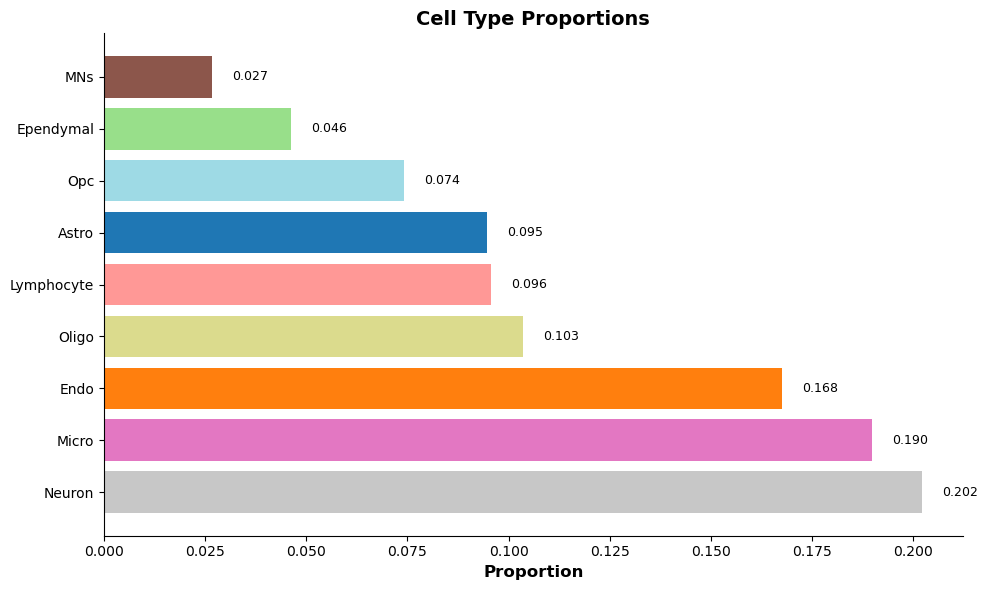

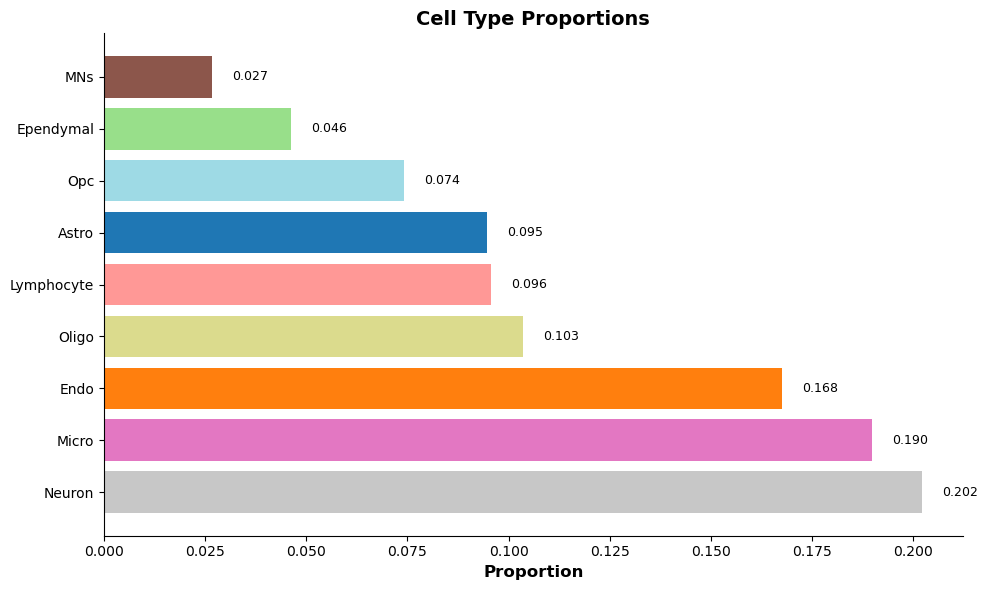

In [14]:
# Overall (all runs combined) cell type proportions from W_full

from dotpy.visualization import plot_cell_type_proportions
import numpy as np

if W_full is None or all_cell_types is None:
    raise ValueError("W_full / all_cell_types not initialized. Run the per-run DOT loop first.")

# Keep only rows where we actually have weights (not all-NaN)
keep = ~np.all(np.isnan(W_full), axis=1)
W_overall = W_full[keep, :]

if W_overall.shape[0] == 0:
    raise ValueError("No non-NaN weight rows found in W_full.")

fig = plot_cell_type_proportions(
    W_overall,
    cell_types=all_cell_types,
    save_path=str(outdir / "proportions__OVERALL.png")
)

fig


In [ ]:
# Box plot of per-run cell type proportions (with mean ± SEM error bars) across all runs
# Uses W_full (cells x cell_types) and spatial_adata.obs["run_id"].

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if W_full is None or all_cell_types is None:
    raise ValueError("W_full / all_cell_types not initialized. Run the per-run DOT loop first.")

run_ids = spatial_adata.obs["run_id"].astype(str).unique()

# ---- aggregate: for each run, compute the mean proportion per cell type ----
rows = []
for rid in run_ids:
    m = (spatial_adata.obs["run_id"].astype(str) == rid).to_numpy()
    w = W_full[m, :]
    if w.size == 0:
        continue

    keep = ~np.all(np.isnan(w), axis=1)
    w = w[keep, :]
    if w.shape[0] == 0:
        continue

    # normalize rows to sum=1 (safe if already normalized)
    rs = np.nansum(w, axis=1, keepdims=True)
    rs[rs == 0] = np.nan
    w_norm = w / rs

    # per-run average (dot proportions)
    mu = np.nanmean(w_norm, axis=0)

    # optional metadata
    sample_label = str(spatial_adata.obs.loc[m, "sample"].astype(str).iloc[0]) if "sample" in spatial_adata.obs else ""
    status = str(spatial_adata.obs.loc[m, "status"].astype(str).iloc[0]) if "status" in spatial_adata.obs else ""

    rows.append([rid, sample_label, status, *mu.tolist()])

cols = ["run_id", "sample", "status", *all_cell_types]
df = pd.DataFrame(rows, columns=cols)

if df.shape[0] < 2:
    raise ValueError(f"Need >=2 runs with valid weights to make boxplots; got {df.shape[0]}.")

# ---- long format for plotting ----
long = df.melt(
    id_vars=["run_id", "sample", "status"],
    value_vars=all_cell_types,
    var_name="cell_type",
    value_name="proportion",
).dropna(subset=["proportion"])

# ---- plot: one box per cell type, across runs ----
# ordering: by median proportion (optional, helps readability)
order = (
    long.groupby("cell_type")["proportion"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

data = [long.loc[long["cell_type"] == ct, "proportion"].to_numpy() for ct in order]
means = [np.mean(x) if len(x) else np.nan for x in data]
sems  = [np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan for x in data]

plt.figure(figsize=(max(10, 0.35 * len(order)), 6))
bp = plt.boxplot(
    data,
    labels=order,
    showfliers=False,
    patch_artist=False
)

x = np.arange(1, len(order) + 1)
plt.errorbar(x, means, yerr=sems, fmt="o", capsize=3)  # mean ± SEM

plt.ylabel("Per-run mean DOT proportion")
plt.title(f"Cell type proportions across runs (n_runs={df.shape[0]})")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()

out_png = outdir / "boxplot__cell_type_proportions_across_runs.png"
plt.savefig(out_png, dpi=200)
plt.show()

print(f"Saved: {out_png}")

# df (wide per-run table) is useful to inspect / export
df.head()


# Run for the whole dataset 

In [7]:
spatial_processed = setup_spatial(
    spatial_adata,
    spatial_key='spatial',
    th_spatial=0.84,
    verbose=True
)

Processing spatial data: (1841872, 541)
Filtered to 397 genes
Finding spatial neighbours...
Estimated spatial radius: 20.82
Finding spatial neighbors (radius=20.82)...
Found 197929 spatial pairs
Spatial data prepared: 1841872 spots, 397 genes
Sparsity: 95.90%


## Run DOT

In [8]:

device = 'cuda' if torch.cuda.is_available() else 'cpu'

dot = DOT(
    spatial_processed,
    ref_processed,
    batch_size=500,          # Adjust for GPU memory
    device=device            # Explicitly set device
)

In [9]:
checkpoints = "/oak/stanford/scg/lab_mpsnyder/johnck/Projects/RK/Spatial/DOT/DOT_checkpoints"

In [10]:
device

'cuda'

In [11]:
dot.fit(
    mode='highres',
    iterations=100,
    checkpoint_dir=checkpoints,  # Save checkpoints
    checkpoint_freq=10,
    verbose=True
)

Optimising on GPU | S=1841872 C=64 G=227 K=9
  batches=3684 × 500 spots | mixed_prec=OFF
Iter   1: obj=2245074.8047  gap=841743872.3590  t= 7.58s, GPU mem=10546MB
  checkpoint → /oak/stanford/scg/lab_mpsnyder/johnck/Projects/RK/Spatial/DOT/DOT_checkpoints/checkpoint_iter_10.pkl
Iter  11: obj=2988259.8459  gap=193802895.3681  t= 2.70s, GPU mem=11586MB
  checkpoint → /oak/stanford/scg/lab_mpsnyder/johnck/Projects/RK/Spatial/DOT/DOT_checkpoints/checkpoint_iter_20.pkl
Iter  21: obj=2980050.8925  gap=92509752.3116  t= 2.61s, GPU mem=11586MB
  checkpoint → /oak/stanford/scg/lab_mpsnyder/johnck/Projects/RK/Spatial/DOT/DOT_checkpoints/checkpoint_iter_30.pkl
Iter  31: obj=2978266.0689  gap=60013476.0747  t= 2.58s, GPU mem=11586MB
  checkpoint → /oak/stanford/scg/lab_mpsnyder/johnck/Projects/RK/Spatial/DOT/DOT_checkpoints/checkpoint_iter_40.pkl
Iter  41: obj=2977710.4167  gap=44114963.1144  t= 2.55s, GPU mem=11586MB
  checkpoint → /oak/stanford/scg/lab_mpsnyder/johnck/Projects/RK/Spatial/DOT/DOT

In [13]:
# Get results
weights = dot.get_weights(normalize=True)
cell_types = dot.get_cell_types()

Figure saved to proportions.png


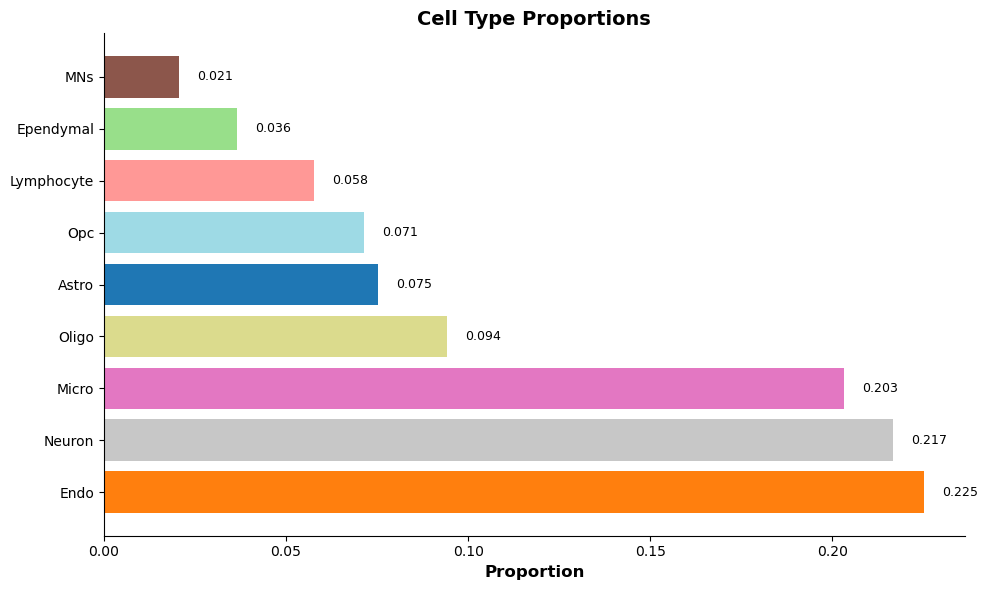

In [14]:
from dotpy.visualization import plot_cell_type_proportions

fig = plot_cell_type_proportions(
    weights,
    cell_types=cell_types,
    save_path='proportions.png'
)

In [16]:
spatial_adata.obs["sample"].cat.categories

Index(['ALS5_Region_2__largecells_reseg_20251217_091151_job49431578_0',
       'SD01015_BG', 'SD01115_BG', 'SD01320_BG', 'SD01413_BA', 'SD01616_BI',
       'SD01620_BI', 'SD01623_BI', 'SD01915_BG', 'SD01922_BI', 'SD01923_BI',
       'SD02022', 'SD02022_BI', 'SD02622_BI', 'SD02913_BA', 'SD03522_BG',
       'SD03614_BG', 'SD03914_BG', 'SD04219_BI'],
      dtype='object')

Figure saved to cell_type_maps.png


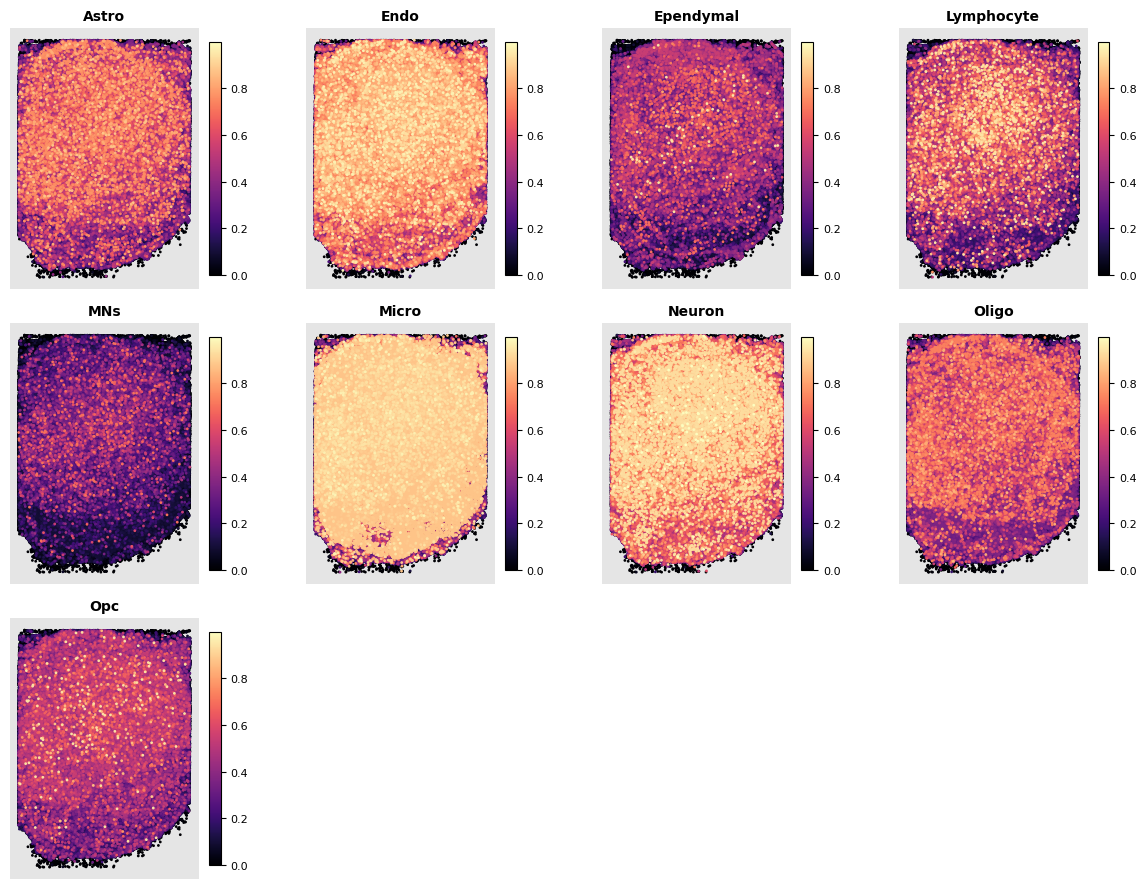

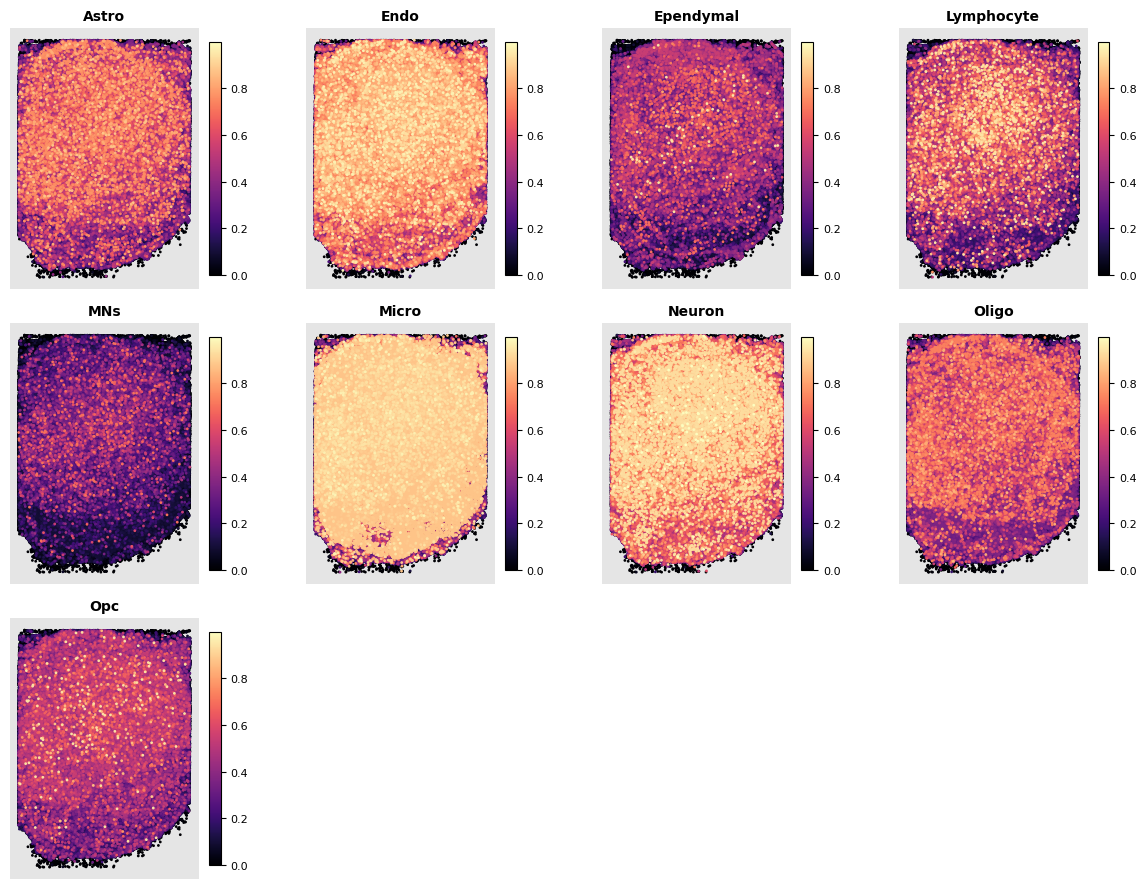

In [17]:
# Visualize results
plot_spatial_weights(
    spatial_adata.obsm['spatial'],
    weights,
    cell_types=cell_types,
    ncols=4,
    save_path='cell_type_maps.png'
)

In [18]:
# Add results to spatial AnnData
spatial_adata.obsm['dot_v1_weights'] = weights

# Add individual cell type columns
for i, ct in enumerate(cell_types):
    spatial_adata.obs[f'dot_{ct}'] = weights[:, i]

# Save
spatial_adata.write('/oak/stanford/scg/lab_mpsnyder/johnck/Projects/RK/Spatial/DOT/(RK)SC_concatenated_with_deconvolution.h5ad')

Figure saved to optimization_history.png


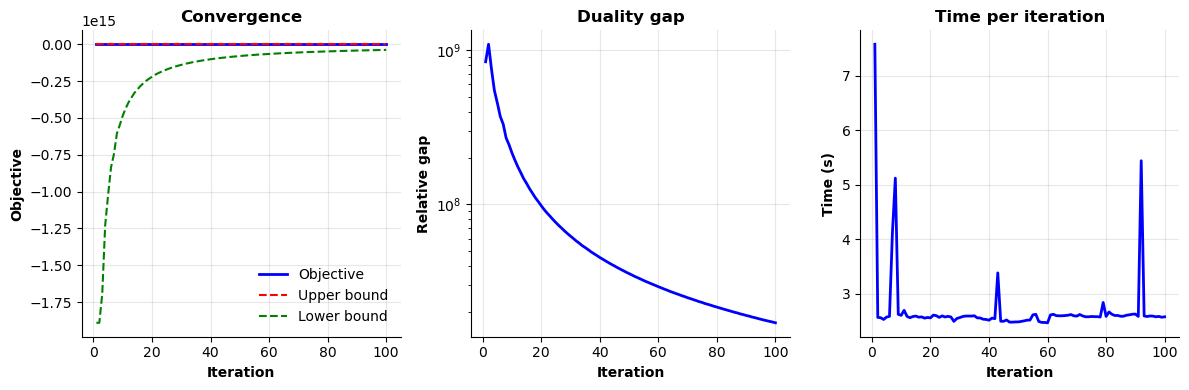

In [19]:
from dotpy.visualization import plot_optimization_history

fig = plot_optimization_history(
    dot.history,
    save_path='optimization_history.png'
)